# ___Summary of hOUwie model fits___
-------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.1 (2026-06-24 ucrt)"


In [40]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("lattice")
    library("ggplot2")
})

# source("../houwie_patches.R")

options(repr.plot.width = 25, repr.plot.height = 15)

In [3]:
packageVersion("OUwie")

[1] '3.0.3'

In [4]:
packageVersion("corHMM")

[1] '2.8'

In [5]:
# the OUMA and OUMVA model issues have been fixed in OUwie versions 3.00 and up, see the below page for details
# https://thej022214.github.io/OUwie/articles/calculationUpdate.html

In [8]:
#--------------------------
# helper functions
#--------------------------

STATE_COLOURS <- c(AM = "#E7BC0C", EcM = "#23B9AF", ErM = "#6B6CF2", NM = "#11E823", NMAM = "#2D2E30", EcMAM = "#E71A23")

compare_houwie_groups <- function(gp_cd, gp_cid){
    tab <- cbind(OUwie::getModelTable(gp_cd, type = "AICc")[, c("AICc", "dAICc")], OUwie::getModelTable(gp_cid, type = "AICc")[, c("AICc", "dAICc")])
    names(tab) <- c("cd_AICc", "cd_dAICc", "cid_AICc", "cid_dAICc")
    tab
}

read_all_rds <- function(dirpath, cd, strip, rm_underscores = TRUE) {
    # dirpath = path to the directory containing the .Rds files
    # cd = character dependent or independent models, these are expected to contain "CD" or "CID" in their names
    # strip = the regex pattern to strip out of the file names when naming objects, can be a plain string as well
    # rm_underscores - strip all the underscores in the object name

    fnames <- list.files(dirpath) # all the files in the specified dir
    if(cd) fnames <- fnames[grep(pattern = "CD", fnames)]
    else fnames <- fnames[grep(pattern = "CID", fnames)] # cherry pick CD or CID models, given their names contain "CD" or "CID" to distinguish them
    # print(fnames)

    paths <- paste0(dirpath, fnames) # relative paths for all the Rds files
    stopifnot(length(fnames)==length(paths))

    # remove the unnecessary parts of the file names to create the model names and also remove all the underscores
    mnames <- fnames |> gsub(pattern = ".Rds", replacement = '') |> gsub(pattern = strip, replacement = '') |> gsub(pattern = ifelse(rm_underscores, '_', ''), replacement = '')
    stopifnot(length(fnames)==length(mnames))
    stopifnot(length(paths)==length(mnames))

    models <- list()
    for (i in seq_along(mnames)) models[[mnames[i]]] <- readRDS(file = paths[i])
    stopifnot(length(models)==length(mnames))

    models
}


convergence_failures <- function(models, strip='', threshold_diff_aicc=1e10){
    model_table <- OUwie::getModelTable(models, type = "AICc") # model table from the models
    model_names <- row.names(model_table)
    model_names <- gsub(pattern = strip, replacement = '', x = model_names) # strip off the specified pattern from the names
    
    aiccs <- model_table[, "AICc"] # this becomes a hard requirement of the function, that the input dataframe needs to have a column named "AICc"
    # so the criteria is that the absoulte difference between the AICc of a given model and the highest AICc (worst fit) shouldn't exceed 1e5, else it's considered a convergence failure
    model_names[abs(aiccs - max(aiccs)) >= threshold_diff_aicc]  # with an option provided to pass in a custom difference threshold
}


plot_model_averages <- function(data){
    # the data argument is expected to be the untouched output of the OUwie::getModelAvgParams() function
    stopifnot(is.data.frame(data))
    
    options(repr.plot.width = 15, repr.plot.height = 15)
    par(mfrow = c(2, 2), mar = c(3, 4, 0, 0), mgp = c(2.25, 0.75, 0))

    boxplot(formula = rates ~ tip_state, data = data, xlab = NULL, ylab = "Rates", border = STATE_COLOURS, col = "white")
    boxplot(formula = alpha ~ tip_state, data = data, xlab = NULL, ylab = expression(alpha), border = STATE_COLOURS, col = "white")
    boxplot(formula = sigma.sq ~ tip_state, data = data, xlab = NULL, ylab = expression(sigma^2), border = STATE_COLOURS, col = "white")
    boxplot(formula = theta ~ tip_state, data = data, xlab = NULL, ylab = expression(theta), border = STATE_COLOURS, col = "white")
}

In [8]:
# find out the AIC and AICc of all the models

# OUwie::getModelAvgParams()
# type - one of AIC, BIC, or AICc for use during evaluation of relative model fit.
# AICc (small sample size corrected AIC) is the best option for datasets with a few number of species.
# force - a boolean indicating whether to force potentially failed model fits to be included in the model averaging.

# look up to see what the BIC stuff is about https://www.rdocumentation.org/packages/AICcmodavg/versions/2.3-4/topics/bictabCustom
# AIC vs BIC https://fiveable.me/bayesian-statistics/unit-11/bayesian-information-criterion/study-guide/o3iS2biLgz7mcyuv

# ___Parameter Tuning___
---------------------

In [9]:
# inspect the old hOUwie fits to optimize future fits

models_cd <- read_all_rds("../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = TRUE, strip = "_F00679_CD")
models_cid <- read_all_rds("../../data/chapter2/rdata/parallel/rd_1301_100sims/", cd = FALSE, strip = "_F00679_CID")

In [12]:
model <- readRDS("../../data/chapter2/rdata/parallel/rd_1301_100sims/SYMOUMA_F00679_CID.Rds")

# https://github.com/thej022214/OUwie/blob/master/R/hOUwie.R#L110
setNames(model$ub_continuous_model, nm = c("alpha", "sigma", "theta")) # bounds of the continuous trait are in the following order - c(lb.alpha,lb.sigma,lb.optim)

alpha       sigma       theta 
  0.1729462   0.1729462 499.9899950

In [13]:
model$ub_discrete_model

[1] 24.95087

In [14]:
model$lb_continuous_model

[1] 0.0000000001 0.0000000001 4.7450490827

In [15]:
model$lb_discrete_model

[1] 2.495087e-07

In [16]:
model$solution.cont

,(1A),(2A),(3A),(4A),(5A),(6A),(1B),(2B),(3B),(4B),(5B),(6B)
alpha,0.009615693,0.009615693,0.009615693,0.009615693,0.009615693,0.009615693,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05,2.229048e-05
sigma2,0.172946239,0.172946239,0.172946239,0.172946239,0.172946239,0.172946239,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01
theta,-45.254950917,-45.254950917,-45.254950917,-45.254950917,-45.254950917,-45.254950917,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02,1.079381e+02


In [18]:
apply(model$solution.cont, MARGIN = 1, FUN = min)

alpha        sigma2         theta 
 2.229048e-05  1.729462e-01 -4.525495e+01

In [109]:
# upper and lower bounds of discrete and continuous models
# everything looks identical (these are defaults?? - not model estimated parameters!!!)

mapply(models_cd, FUN = function(x) list(UBC = x$ub_continuous_model, LBC = x$lb_continuous_model, UBD = x$ub_discrete_model, LBD = x$lb_discrete_model)) |> t() |> as.data.frame()

,UBC,LBC,UBD,LBD
,<named list>,<named list>,<named list>,<named list>
ARDOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
SYMOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07


In [81]:
mapply(models_cid, FUN = function(x) list(UBC = x$ub_continuous_model, LBC = x$lb_continuous_model, UBD = x$ub_discrete_model, LBD = x$lb_discrete_model)) |> t() |> as.data.frame()

,UBC,LBC,UBD,LBD
,<named list>,<named list>,<named list>,<named list>
ARDOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
ARDOUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMV,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
EROUMVA,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07
SYMOUM,"0.1729462, 0.1729462, 499.9899950","0.0000000001, 0.0000000001, 4.7450490827",24.95087,2.495087e-07


In [89]:
# transition rates

mapply(models_cd, FUN = function(x) list(dmax = max(x$solution.disc, na.rm = TRUE), dmin = min(x$solution.disc, na.rm = TRUE))) |> t() |> as.data.frame()

,dmax,dmin
,<named list>,<named list>
ARDOUM,0.006338935,1.373761e-06
ARDOUMA,0.0002656235,8.090315e-06
ARDOUMV,0.004001858,1.182816e-05
ARDOUMVA,0.0002656235,8.66839e-06
EROUM,0.0002238004,0.0002238004
EROUMA,6.801639,6.801639
EROUMV,0.0002022754,0.0002022754
EROUMVA,0.008399754,0.008399754
SYMOUM,0.0007361478,4.140943e-07


In [92]:
mapply(models_cid, FUN = function(x) list(dmax = max(x$solution.disc, na.rm = TRUE), dmin = min(x$solution.disc, na.rm = TRUE))) |> t() |> as.data.frame()

,dmax,dmin
,<named list>,<named list>
ARDOUM,0.0003752032,0.0001675971
ARDOUMA,0.0002656235,4.723529e-05
ARDOUMV,0.0002656235,0.0002656235
ARDOUMVA,0.02656235,0.0001214134
EROUM,0.0003812546,5.16566e-05
EROUMA,0.01278417,2.495087e-07
EROUMV,0.0007774337,8.399754e-05
EROUMVA,0.006779943,0.0002656235
SYMOUM,0.000336724,5.972368e-06


In [1]:
# for continuous models the sequence is c(alpha, sigma, theta)

In [24]:
# CD fits - continuous model params - maxes

mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) # this returns the max of each params for different states within each fits

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
alpha,2.738273e-07,0.02175001,5.848399e-09,0.02175001,1.047976e-10,0.04528611,1.060156e-10,0.01961547,1.476953e-10,2.118098e-03,1.399549e-10,0.06060018
sigma2,1.729462e-01,0.17294624,1.729462e-01,0.05469040,1.729462e-01,0.17294624,1.729462e-01,0.17294624,1.729462e-01,1.729462e-01,1.729462e-01,0.17294624
theta,4.499900e+02,-0.91082740,4.499900e+02,0.98686036,1.940909e+02,3.18866445,3.251291e+02,107.27723423,1.074415e+02,1.559061e+02,1.421200e+02,125.05260777


In [27]:
mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) |> apply(FUN = max, MARGIN = 1) # max across all the fits

alpha       sigma2        theta 
  0.06060018   0.17294624 449.98999500

In [28]:
mapply(models_cd, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = min, na.rm = TRUE)) |> apply(FUN = min, MARGIN = 1) # min across all the fits

alpha        sigma2         theta 
 1.000000e-10  1.355719e-06 -4.525495e+01

In [30]:
# CID fits

mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE))

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
alpha,7.289750e-05,0.01457781,5.469040e-08,0.02059171,5.442531e-05,5.469040e-05,5.469040e-05,5.472754e-05,1.766810e-05,9.615693e-03,7.100862e-09,9.725482e-03
sigma2,1.729462e-01,0.17294624,1.729462e-01,0.17294624,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01,1.729462e-01
theta,1.126031e+02,98.57260218,1.079381e+02,107.93811043,1.574389e+02,1.645572e+02,1.205584e+02,1.051561e+02,4.499900e+02,1.079381e+02,1.236215e+02,1.079381e+02


In [31]:
mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = max, na.rm = TRUE)) |> apply(FUN = max, MARGIN = 1) # max across all the fits

alpha       sigma2        theta 
  0.02059171   0.17294624 449.98999500

In [32]:
mapply(models_cid, FUN = function(x) apply(x$solution.cont, MARGIN = 1, FUN = min, na.rm = TRUE)) |> apply(FUN = min, MARGIN = 1) # min across all the fits

alpha        sigma2         theta 
 7.100862e-09  7.293082e-04 -4.525495e+01

# ___1301 species, 6 states and FRED 4.0 post `houwie-update`___
---------------------------

# $t_{1/2} = \frac{log(2)}{\alpha}$
	
# $V_{stationary} = \frac{\sigma^2}{2 \alpha}$

In [ ]:
# https://github.com/thej022214/OUwie/tree/houwie-update

## ___1. RD___

In [6]:
rd_new_cd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/RD/", cd = TRUE, strip = "_F00679_CD_100")
rd_new_cid <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/RD/", cd = FALSE, strip = "_F00679_CID_100")

In [9]:
compare_houwie_groups(gp_cd = rd_new_cd, gp_cid = rd_new_cid)

,cd_AICc,cd_dAICc,cid_AICc,cid_dAICc
,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,2098.888,34.624896,2131.622,178.74853
ARDOUMA,2099.952,35.689324,2183.217,230.34315
ARDOUMV,2104.127,39.864290,2191.354,238.48002
ARDOUMVA,2107.334,43.071096,2179.583,226.70942
EROUM,2075.291,11.027671,1979.335,26.46103
EROUMA,2079.693,15.430454,2042.813,89.93860
EROUMV,2078.052,13.788505,1997.292,44.41784
EROUMVA,2064.263,0.000000,2022.109,69.23474
SYMOUM,2072.293,8.030229,2015.156,62.28230


In [11]:
# model averages for RD

rd_avgs_cd <- OUwie::getModelAvgParams(rd_new_cd, type = "AICc", force = FALSE)
rd_avgs_cid <- OUwie::getModelAvgParams(rd_new_cid, type = "AICc", force = FALSE)

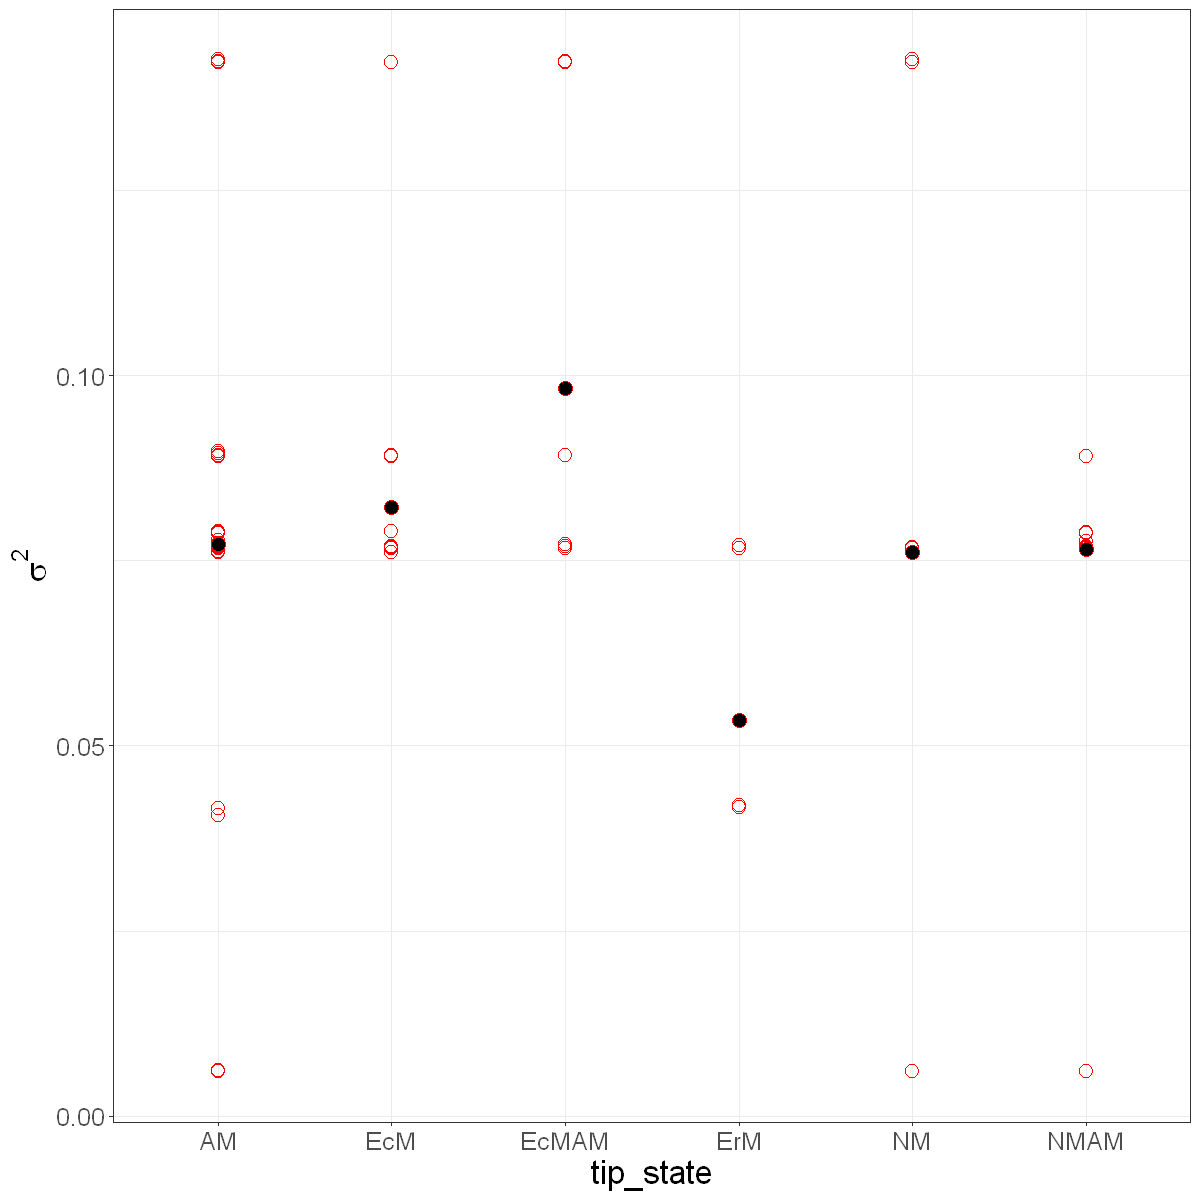

In [72]:
options(repr.plot.width = 10, repr.plot.height = 10)

ggplot2::ggplot() + 
    theme_bw() +
    geom_point(aes(x = tip_state, y = sigma.sq), colour = "red", pch = 21, size = 3.5, data = rd_avgs_cd, show.legend = FALSE) + 
    stat_summary(aes(x = tip_state, y = sigma.sq), fun = "mean", inherit.aes = FALSE, data = rd_avgs_cd, geom = "point", size = 4, fill = "black", colour = "red", pch = 21) + 
    ylab(expression(sigma^2)) +
    theme(axis.title = element_text(size = 20), axis.text = element_text(size = 15))

In [13]:
srl_new_cd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/SRL/", cd = TRUE, strip = "_F00727_CD_100")
srl_new_cid <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/SRL/", cd = FALSE, strip = "_F00727_CID_100")

In [15]:
compare_houwie_groups(gp_cd = srl_new_cd, gp_cid = srl_new_cid)

,cd_AICc,cd_dAICc,cid_AICc,cid_dAICc
,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,4657.949,23.5624555,5635.152,1063.44479
ARDOUMA,4657.611,23.2248490,4817.148,245.44151
ARDOUMV,4659.377,24.9905889,4879.470,307.76324
ARDOUMVA,4668.528,34.1416139,4836.704,264.99686
EROUM,4638.037,3.6512844,4694.788,123.08090
EROUMA,4638.675,4.2893312,4674.920,103.21332
EROUMV,4640.217,5.8312388,4673.078,101.37120
EROUMVA,4642.393,8.0064163,4677.195,105.48769
SYMOUM,4634.904,0.5182975,4692.620,120.91262


In [16]:
rtd_new_cd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/RTD/", cd = TRUE, strip = "_F00709_CD_100")
rtd_new_cid <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/houwie-update/RTD/", cd = FALSE, strip = "_F00709_CID_100")

In [17]:
compare_houwie_groups(gp_cd = rtd_new_cd, gp_cid = rtd_new_cid)

,cd_AICc,cd_dAICc,cid_AICc,cid_dAICc
,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,2896.939,37.096476,2957.291,334.06563
ARDOUMA,2899.130,39.287478,2905.792,282.56677
ARDOUMV,2887.144,27.301415,2770.727,147.50178
ARDOUMVA,2884.552,24.710057,3017.716,394.49059
EROUM,2926.671,66.828876,2922.310,299.08525
EROUMA,2880.056,20.213669,2919.569,296.34419
EROUMV,2866.298,6.455883,2898.572,275.34693
EROUMVA,2862.624,2.781402,2623.225,0.00000
SYMOUM,2874.826,14.983327,2940.056,316.83097


## ___Fine root subset comparison___
--------------------

In [7]:
# root diameter <= 2.00 mm subset
cd_diamater_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679D/", cd = TRUE, strip = "_F00679D_CD_200") # CD fits
cid_diamater_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679D/", cd = FALSE, strip = "_F00679D_CID_200") # CID fits

# root order <= 3 subset
cd_order_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679O/", cd = TRUE, strip = "_F00679O_CD_200") # CD fits
cid_order_rd <- read_all_rds("../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679O/", cd = FALSE, strip = "_F00679O_CID_200") # CID fits

In [19]:
OUwie::getModelTable(cd_diamater_rd, type = "AICc")["AICc"] |> t() # lowest is EROUMA - 1195.924

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
AICc,1359.014,2787.785,1318.745,4316.879,4171.651,1195.924,10650.3,15541.25,1344.107,5975.95,41352.25,10140.35


In [20]:
OUwie::getModelTable(cid_diamater_rd, type = "AICc")["AICc"] |> t() # lowest is EROUMV - 1207.401

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
AICc,30713.65,1340.778,285009.2,57828.27,490695.1,1532.076,1207.401,2057.695,1294.351,2509.911,12632.29,2429.756


In [23]:
OUwie::getModelTable(cd_order_rd, type = "AICc")["AICc"] |> t() # lowest is ARDOUM - 1046.341417652

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
AICc,1046.341,1476.868,4256.846,1276.143,21453.87,3878.766,1083.133,1261.681,128936,1600.766,1292.41,251415.7


In [26]:
OUwie::getModelTable(cid_order_rd, type = "AICc")["AICc"] |> t() # lowest is EROUM - 975.2466

,ARDOUM,ARDOUMA,ARDOUMV,ARDOUMVA,EROUM,EROUMA,EROUMV,EROUMVA,SYMOUM,SYMOUMA,SYMOUMV,SYMOUMVA
AICc,1694.284,2045.797,3488.436,2344.013,975.2466,2322.755,121970.7,2300.44,5007.716,3374.225,1205.77,1369.549


In [8]:
capture.output(diameter_subset_rd_averages_cd <- OUwie::getModelAvgParams(cd_diamater_rd, type = "AICc", force = FALSE), file = nullfile())
capture.output(diameter_subset_rd_averages_cid <- OUwie::getModelAvgParams(cid_diamater_rd, type = "AICc", force = FALSE), file = nullfile())

capture.output(diameter_subset_ord_averages_cd <- OUwie::getModelAvgParams(cd_order_rd, type = "AICc", force = FALSE), file = nullfile())
capture.output(diameter_subset_ord_averages_cid <- OUwie::getModelAvgParams(cid_order_rd, type = "AICc", force = FALSE), file = nullfile())

In [16]:
rbind(
    cbind(diameter_subset_rd_averages_cd, criteria = "RD", cd = TRUE),
    cbind(diameter_subset_rd_averages_cid, criteria = "RD", cd = FALSE),
    cbind(diameter_subset_ord_averages_cd, criteria = "ORDER", cd = TRUE),
    cbind(diameter_subset_ord_averages_cid, criteria = "ORDER", cd = FALSE)
) |> write.csv("../../data/chapter2/ModelAvgParams_RD_fineroot_criteria_comparison.csv", row.names = FALSE)